# Orbital Maneuvers

## The Rocket Equation

In order to transition from an orbit to another we need to modify the amount of energy by performing a maneuver. During an engine burn, part of the spacecraft's fuel mass is expelled with high velocity, accelerating the spacecraft along the opposite direction. The resulting change of velocity $\Delta v$ is related to the engine's performances and the amount of expelled mass by the **Tsiolkovsky rocket equation**:

#### $$ \Delta v = I_{sp}gln\frac{m_0}{m_f}$$

$I_{sp}$ is the **specific impulse**, a phisical quantity (measured in seconds) which measures how efficiently an engine generates thrust from propellant.  It can be understood as the time that one kilogram of fuel can produce one kilogram of thrust: the engine with the higher value of specific impulse is more efficient because it produces more thrust for the same amount of propellant.

In practical terms, the specific impulse is only function of the velocity of the exhaust gases from the engine ($v_e$) and the gravitational constant:

#### $$I_{sp} = \frac{v_e}{g} \mapsto \Delta v = v_eln\frac{m_0}{m_f}$$

The rocket equation can be rearranged to evaluate the mass of propellant needed to generate a specific amount of $\Delta v$:

#### $$ \Delta m = m_0\left ( 1-e^{-\frac{\Delta v}{v_e}} \right )$$


Also, the duration of a maneuver to produce a specific $\Delta v$ is

#### $$\Delta t = \frac{\Delta m}{\dot{m}}, \dot{m}=\frac{T_{hrust}}{v_e}$$

## Impulsive Maneuvers
The most common assumption which is made in the preliminary mission analysis is to consider the maneuver as instantaneous (or **impulsive**). This assumption is reasonable at least when the actual maneuver duration is way shorter than the mission duration itself.

When idealizing the maneuver as an impulsive one, the state vector at maneuver time is suddenly modified in such a way the velocity components reflect the effect of the engine's thrust:

#### $$ \left\{ x, y, z, v_x^-, v_y^-, v_z^-\right\}\mapsto \left\{ x, y, z, v_x^+, v_y^+, v_z^+\right\}$$

, where the $^-$ and $^+$ apex refer to the pre-maneuver and post-maneuver state respectively. Note as the **position remains the same**, while the velocity is changed. The overall amount of velocity change is:

#### $$\Delta v = \sqrt{\left ( v_x^+ - v_x^- \right )^2 + \left ( v_y^+ - v_y^- \right )^2  + \left ( v_z^+ - v_z^- \right )^2 }$$

For the goals of this analysis it is appropriate to decompose the $\Delta V$ along the Radial, In-Track and Cross-track componenents (RIC reference frame):

#### $$\Delta v = \sqrt{\left ( v_R^+ - v_R^- \right )^2 + \left ( v_I^+ - v_I^- \right )^2  + \left ( v_C^+ - v_C^- \right )^2 } =  \sqrt{\Delta v_R^2 + \Delta v_I^2 + \Delta v_C^2}$$

<center><img src="Images/RIC_2.png" alt="Drawing" style="width: 650px;"/><center>

$\quad$


Depending on the values of $\Delta v_C$ we can broadly characterize maneuvers as **in-plane** ($\Delta v_C = 0$) or **out-of plane** ($\Delta v_C \neq 0$): the former can only change the size and shape of the orbit, while the latter can also change inclination and right ascension.




## In-plane Maneuvers

Normally used to raise the apogee/perigee while getting the final orbit (e.g., from LEO to GEO), **the in-plane maneuver only affect the size, the shape and the orientation of the orbit on its plane**. The effects of the maneuver on the resulting (transfer) orbit depends on the size, direction and application point along the initial orbit. A major factor to consider is the **Oberth effect**.

In practical terms, this means that to maximize the energy gain from propulsion, a spacecraft should perform engine burns at the point in its trajectory where its velocity is highest relative to the reference frame (e.g., at the periapsis). The effect was first described by Hermann Oberth in 1927 and is a key principle in orbital mechanics for efficient space travel, such as escaping a planet's gravity or transferring between orbits.

To demonstrate this we need to consider the change in kinetic energy due to the burn:

#### $$ \Delta E_k =E_k^f - E_k^i = \frac{1}{2} m (v + \Delta v)^2 - \frac{1}{2} m v^2$$

Applying some algebra, we get

#### $$\Delta E_k = m v \Delta v + \frac{1}{2} m (\Delta v)^2$$


- The term $\frac{1}{2} m (\Delta v)^2 $ is the kinetic energy change you'd get if the rocket were at rest ($v = 0)$. It's fixed for a given $\Delta v$.
- The additional $m v \Delta v$ depends on the initial velocity $v$. This is the key to the Oberth effect: when $v$ is larger, this term is larger, meaning the total kinetic is greater for the same $\Delta v$.

In other words, the energy gain from the same velocity increment (same fuel burn) is amplified by the rocket's existing speed. This extra energy comes from the interaction between the rocket's motion and the propellant's ejection: the propellant is expelled backward relative to the rocket, but in the inertial frame, it carries away less kinetic energy when the rocket is moving faster forward, leaving more for the rocket.

For example, consider a satellite orbiting the Earth with the following parameters:

- Altitude of periapsis = 250 km
- Altitude of apoapsis = 15000 km ($e$ = 0.527)

If we apply a 200 m/sec $\Delta v$ at perigee, we get a semimajor axis $a$ = 16200 km, while if we apply the same burn at apoapsis we get $a$ = 14600 km.


The code below evaluates the effects of an in-track maneuver ($\Delta v_I$ only) performed at different locations along the orbit (namely, the true anomaly varies from 0 to 359 degrees). Note as the semimajor axis (size), eccentricity (shape) and argument of perigee (orientation) are affected and how they relate with the maneuver application location

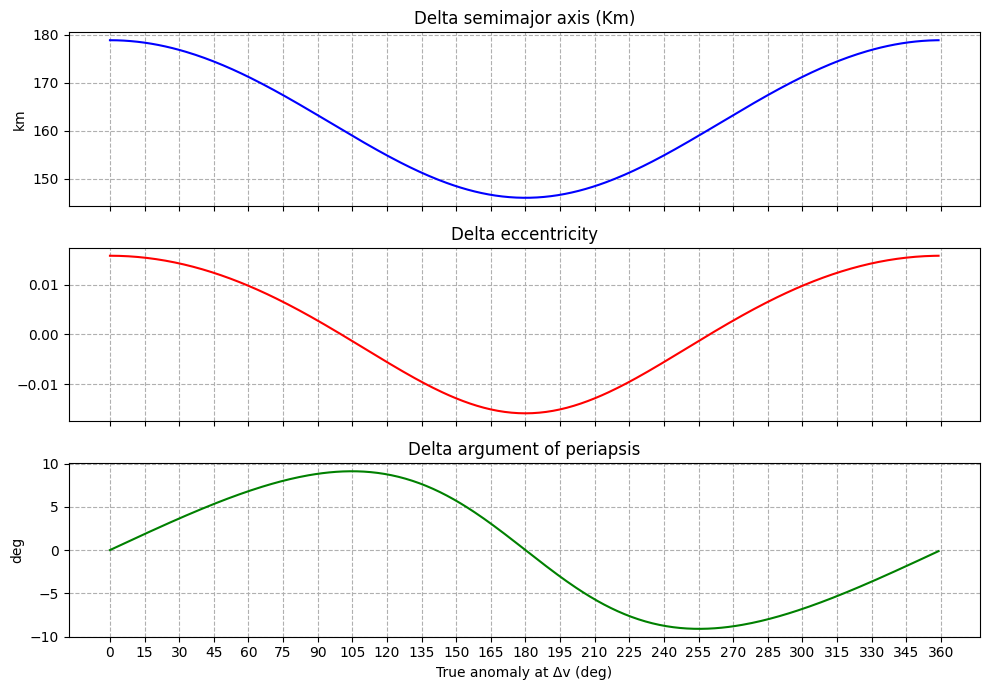

In [1]:
from routines import *
from astrodynamics import *
import math

########################################## INPUT DATA ##########################################################
init_sma = 10000 # km
init_ecc = 0.1 # initial eccentricity
delta_v = 50 # m/sec
################################################################################################################

PlotIntrakManEffects(init_sma, init_ecc, delta_v)

## Out-of-Plane Maneuvers

This is a generic definition to highlight that the applied $\Delta v$ has a component along the normal of the orbit plane. This is normally applied to change the orbit inclination and/or the RAAN. Let's consider a pure out of plane maneuver ($\Delta v$ along the orbit normal direction): the orbit plane will be rotated by an angle $\delta$

<center><img src="Images/outOfPlane1.png" alt="Drawing" style="width: 450px;"/><center>

$\quad$

The amount of $\Delta v$ required to reach a specific $\delta$ is:

#### $$  \Delta v = \sqrt{v_i^2+v_f^2-2v_iv_fcos \delta }$$


It can be noted that the magnitude of the final velocity $v_f$ is actually greater than the initial velocity one: this means that the orbit now has more energy and, in turns, a greater semimajor axis. To avoid this effect the direction of the applied $\Delta v$ shall compensate for this velocity increment:

<center><img src="Images/outOfPlane2.png" alt="Drawing" style="width: 450px;"/><center>

In this case $v_i=v_f=v$ and the amount of $\Delta v$ is:

#### $$ \Delta v = 2v sin\frac{\delta }{2}$$

the thrust direction shall be

#### $$90° + \frac{\delta}{2}$$

As visible from the above analytical relationship, for any intended plane rotation the required $\Delta v$ is minimized when $v$ is minimized: this happens when the satellite is located at the apogee. Note as **this is the opposite of the in-plane maneuver**, highlighting the perigee and the apogee as the two critical points where to perform the in-plane and out-of-plane maneuvers respectively.

Another factor to consider is *where* the maneuver has to be performed. From the VOP equations described in the Generalized Perturbations Analysis lecture, we know that variations in RAAN and inclunation are due to perturbations along the orbit normal:

 $$\frac{d\Omega}{dt}=\frac{r\sin u}{na^2\sqrt{1-e^2}\sin i}\textbf{N}$$

   $$\frac{di}{dt}=\frac{r \cos u}{na^2\sqrt{1-e^2}}\textbf{N}$$

,where $  u  $ is the argument of latitude (angular position from the ascending node).

So, the general effect for any out-of-plane maneuver is both an inclination and a RAAN change, but there are two special cases to consider:







### Pure Inclination Change

 $$\frac{d \Omega}{d t} =0\mapsto u=k\pi, k =0,1,..,n $$

 These positions correspond with the line of nodes (where the orbit intercepts the equatorial plane):

 <center><img src="Images/planeChange.png" alt="Drawing" style="width: 550px;"/><center>

$\quad$



### Pure RAAN Change

  $$\frac{d i}{d t} =0\mapsto u=k\frac{\pi}{2}, k =0,1,..,n$$

These positions correspond to the maximum/minimum orbital latitude ($±i$ for inclination $i$), where the velocity is parallel to the equatorial plane, allowing the normal burn to purely rotate the node without tilting the plane's inclination:

 <center><img src="Images/planeChange_2.png" alt="Drawing" style="width: 550px;"/><center>

$\quad$
